In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as nc

In [3]:
import xarray as xr
import glob

# ---------------------------
# 1. find all ERA5 files
# ---------------------------
path = "../.data/ERA5/"
files = sorted(glob.glob(path + "era5_t2m_dailymax_*.nc"))

print(f"Number of files: {len(files)}")
print(files[:3], "...", files[-3:])

# ---------------------------
# 2. read and clean each file
# ---------------------------
datasets = []

for f in files:
    ds = xr.open_dataset(f)

    # drop the useless scalar coordinate if present
    if "number" in ds.coords:
        ds = ds.drop_vars("number")

    # rename coordinates and variable to match GRIDMET
    ds = ds.rename(
        {
            "valid_time": "day",
            "latitude": "lat",
            "longitude": "lon",
            "t2m": "air_temperature",
        }
    )

    datasets.append(ds)

# ---------------------------
# 3. concatenate along the ERA5 time dimension
# ---------------------------
ds_era5 = xr.concat(datasets, dim="day").sortby("day")

ds_era5

Number of files: 78
['../.data/ERA5/era5_t2m_dailymax_2000_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_t2m_dailymax_2000_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_t2m_dailymax_2000_08_aug_utc-04_47N-37N_80W-60W.nc'] ... ['../.data/ERA5/era5_t2m_dailymax_2025_06_jun_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_t2m_dailymax_2025_07_jul_utc-04_47N-37N_80W-60W.nc', '../.data/ERA5/era5_t2m_dailymax_2025_08_aug_utc-04_47N-37N_80W-60W.nc']


<xarray.Dataset> Size: 32MB
Dimensions:          (day: 2392, lat: 41, lon: 81)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 328B 47.0 46.75 46.5 ... 37.5 37.25 37.0
  * lon              (lon) float64 648B -80.0 -79.75 -79.5 ... -60.25 -60.0
Data variables:
    air_temperature  (day, lat, lon) float32 32MB 291.7 290.7 ... 298.5 298.5
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-09T21:06 GRIB to CDM+CF via cfgrib-0.9.1...

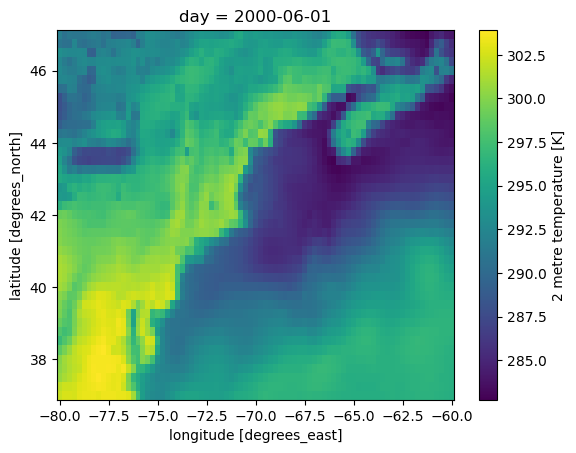

In [7]:
ds_era5.air_temperature.isel(day=0).plot()

In [9]:
grid_path = "../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc"
# Get the GRIDMET spatial extent
ds_grid = xr.open_dataset(grid_path)
lat_min = float(ds_grid.lat.min())
lat_max = float(ds_grid.lat.max())
lon_min = float(ds_grid.lon.min())
lon_max = float(ds_grid.lon.max())

print(lat_min, lat_max, lon_min, lon_max)

37.025000000000006 46.983333333333334 -79.97499996666667 -67.05833330000002


In [10]:
# Slice ERA5 to the same lat/lon extent as GRIDMET
ds_era5_sub = ds_era5.sel(
    lat=slice(lat_max, lat_min),   # ERA5 lat is descending
    lon=slice(lon_min, lon_max)
)

ds_era5_sub

<xarray.Dataset> Size: 19MB
Dimensions:          (day: 2392, lat: 39, lon: 51)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 312B 46.75 46.5 46.25 ... 37.75 37.5 37.25
  * lon              (lon) float64 408B -79.75 -79.5 -79.25 ... -67.5 -67.25
Data variables:
    air_temperature  (day, lat, lon) float32 19MB 290.6 290.6 ... 297.8 297.8
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-09T21:06 GRIB to CDM+CF via cfgrib-0.9.1...

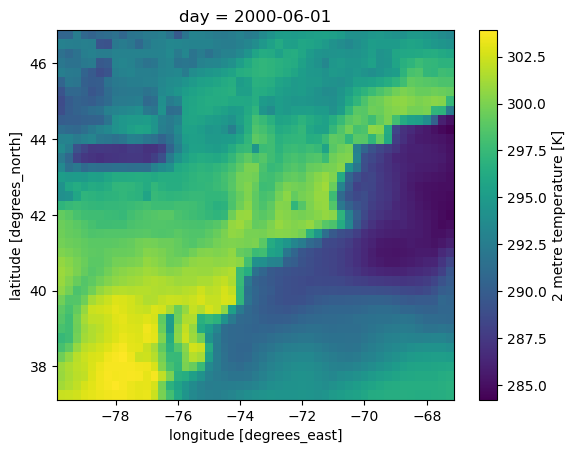

In [11]:
ds_era5_sub.air_temperature.isel(day=0).plot()

In [15]:
# Read GRIDMET
ds_grid = xr.open_dataset("../.data/GRIDMET/gridmet_4km_jja_ne/tmmx_JJA_NE_2000_2025.nc")

# Build a land mask on the GRIDMET grid
land_mask_gridmet = ds_grid["air_temperature"].notnull().any(dim="day")

# Convert bool mask to integer before interpolation
land_mask_gridmet_num = land_mask_gridmet.astype(int)

# Interpolate the GRIDMET mask to the ERA5 subset grid
land_mask_era5 = land_mask_gridmet_num.interp(
    lat=ds_era5_sub.lat,
    lon=ds_era5_sub.lon,
    method="nearest"
)

# Convert back to boolean
land_mask_era5 = land_mask_era5.fillna(0).astype(bool)

# Apply mask to ERA5
ds_era5_sub_masked = ds_era5_sub.where(land_mask_era5)

ds_era5_sub_masked

<xarray.Dataset> Size: 19MB
Dimensions:          (day: 2392, lat: 39, lon: 51)
Coordinates:
  * day              (day) datetime64[ns] 19kB 2000-06-01 ... 2025-08-31
  * lat              (lat) float64 312B 46.75 46.5 46.25 ... 37.75 37.5 37.25
  * lon              (lon) float64 408B -79.75 -79.5 -79.25 ... -67.5 -67.25
Data variables:
    air_temperature  (day, lat, lon) float32 19MB nan nan nan ... nan nan nan
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-09T21:06 GRIB to CDM+CF via cfgrib-0.9.1...

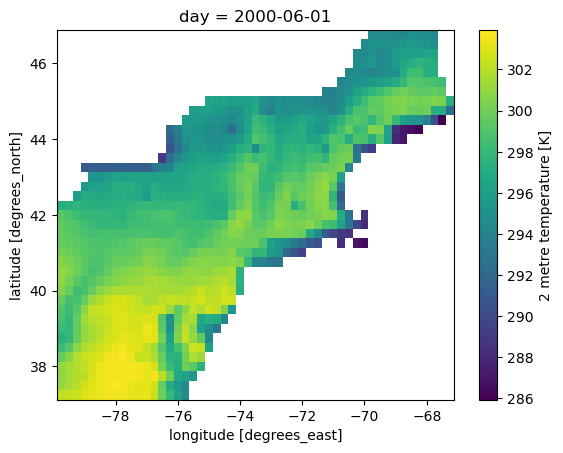

In [16]:
ds_era5_sub_masked.air_temperature.isel(day=0).plot()

In [17]:
save_path = "../.data/ERA5/era5_air_temperature_JJA_NE_2000_2025_masked.nc"
ds_era5_sub_masked.to_netcdf(save_path)